usage of DETR trained on COCO for VOC2012, need to finetune on VOC2012 for better performance

In [1]:
! pip install transformers
! pip install timm

In [2]:
import torch
from torchvision.datasets import VOCDetection
from transformers import DetrImageProcessor, DetrForObjectDetection
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

/Users/wick/computer_vision/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
if torch.cuda.is_available():
    dev = "cuda:0"
elif torch.backends.mps.is_available():
    dev = "mps"
else:
    dev = "cpu"
device = torch.device(dev)
device

device(type='mps')

In [4]:
dataset = VOCDetection(
    root="./VOCdevkit",
    year="2012",
    image_set="val",
    download=False,
)

In [5]:
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")
model.eval()

/Users/wick/computer_vision/.venv/lib/python3.13/site-packages/torch/nn/modules/module.py:2409: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/Users/wick/computer_vision/.venv/lib/python3.13/site-packages/torch/nn/modules/module.py:2409: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/Users/wick/computer_vision/.venv/lib/python3.13/site-packages/torch/nn/modules/module.py:2409: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta p

DetrForObjectDetection(
  (model): DetrModel(
    (backbone): DetrConvModel(
      (conv_encoder): DetrConvEncoder(
        (model): FeatureListNet(
          (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
          (bn1): DetrFrozenBatchNorm2d()
          (act1): ReLU(inplace=True)
          (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          (layer1): Sequential(
            (0): Bottleneck(
              (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn1): DetrFrozenBatchNorm2d()
              (act1): ReLU(inplace=True)
              (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (bn2): DetrFrozenBatchNorm2d()
              (drop_block): Identity()
              (act2): ReLU(inplace=True)
              (aa): Identity()
              (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      

In [6]:
# VOC class names (COCO format that DETR uses)
VOC_CLASSES = [
    'N/A', 'person', 'bicycle', 'car', 'motorbike', 'aeroplane', 'bus',
    'train', 'N/A', 'boat', 'N/A', 'N/A', 'N/A', 'N/A',
    'N/A', 'N/A', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'N/A', 'N/A', 'N/A', 'N/A', 'N/A', 'N/A', 'N/A', 'N/A', 'N/A',
    'N/A', 'N/A', 'N/A', 'N/A', 'N/A', 'N/A', 'N/A',
    'N/A', 'N/A', 'N/A', 'N/A', 'N/A', 'N/A',
    'bottle', 'N/A', 'N/A', 'N/A', 'N/A', 'N/A', 'N/A', 'N/A',
    'N/A', 'N/A', 'N/A', 'N/A', 'N/A', 'N/A', 'N/A', 'N/A',
    'N/A', 'N/A', 'chair', 'sofa', 'pottedplant', 'N/A', 'N/A', 'diningtable',
    'N/A', 'N/A', 'N/A', 'N/A', 'tvmonitor', 'N/A', 'N/A', 'N/A', 'N/A', 'N/A',
    'N/A', 'N/A', 'N/A', 'N/A', 'N/A', 'N/A', 'N/A',
    'N/A', 'N/A', 'N/A', 'N/A', 'N/A', 'N/A'
]

In [7]:
def show_detection_result(image, predictions, target_boxes=None, target_labels=None):
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(image)
    
    # Draw predicted boxes
    if predictions is not None:
        boxes = predictions['boxes'].cpu().numpy()
        scores = predictions['scores'].cpu().numpy()
        labels = predictions['labels'].cpu().numpy()
        
        for box, score, label in zip(boxes, scores, labels):
            if score > 0.5:  # Only show high-confidence predictions
                x1, y1, x2, y2 = box
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                                       linewidth=2, edgecolor='red', facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, y1-5, f'{VOC_CLASSES[label]}: {score:.2f}', 
                       color='red', fontsize=8, bbox=dict(boxstyle="round,pad=0.3", facecolor='white'))
    
    # Draw ground truth boxes (if provided)
    if target_boxes is not None and target_labels is not None:
        for box, label in zip(target_boxes, target_labels):
            x1, y1, x2, y2 = box
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                                   linewidth=2, edgecolor='blue', facecolor='none', linestyle='--')
            ax.add_patch(rect)
            ax.text(x1, y1+10, f'GT: {label}', 
                   color='blue', fontsize=8, bbox=dict(boxstyle="round,pad=0.3", facecolor='white'))
    
    ax.set_title("DETR Object Detection on VOC2012")
    ax.axis('off')
    plt.tight_layout()
    plt.show()

In [8]:
def parse_voc_annotation(annotation):
    """parse VOC XML annotation to extract bounding boxes and labels"""
    boxes = []
    labels = []
    
    for obj in annotation['annotation']['object']:
        bbox = obj['bndbox']
        x1 = float(bbox['xmin'])
        y1 = float(bbox['ymin'])
        x2 = float(bbox['xmax'])
        y2 = float(bbox['ymax'])
        boxes.append([x1, y1, x2, y2])
        labels.append(obj['name'])
    
    return boxes, labels

run detection on a few samples

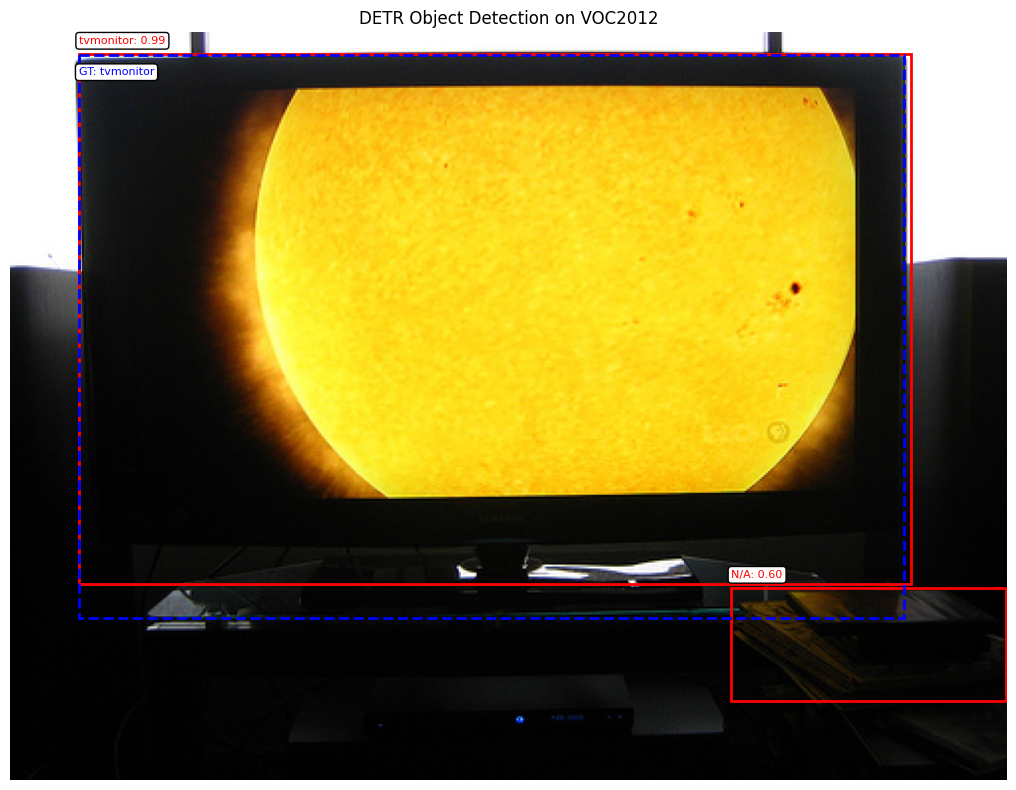

Sample 1:
  Ground truth objects: 1
  Predicted objects: 2
  High-confidence predictions: 2
--------------------------------------------------


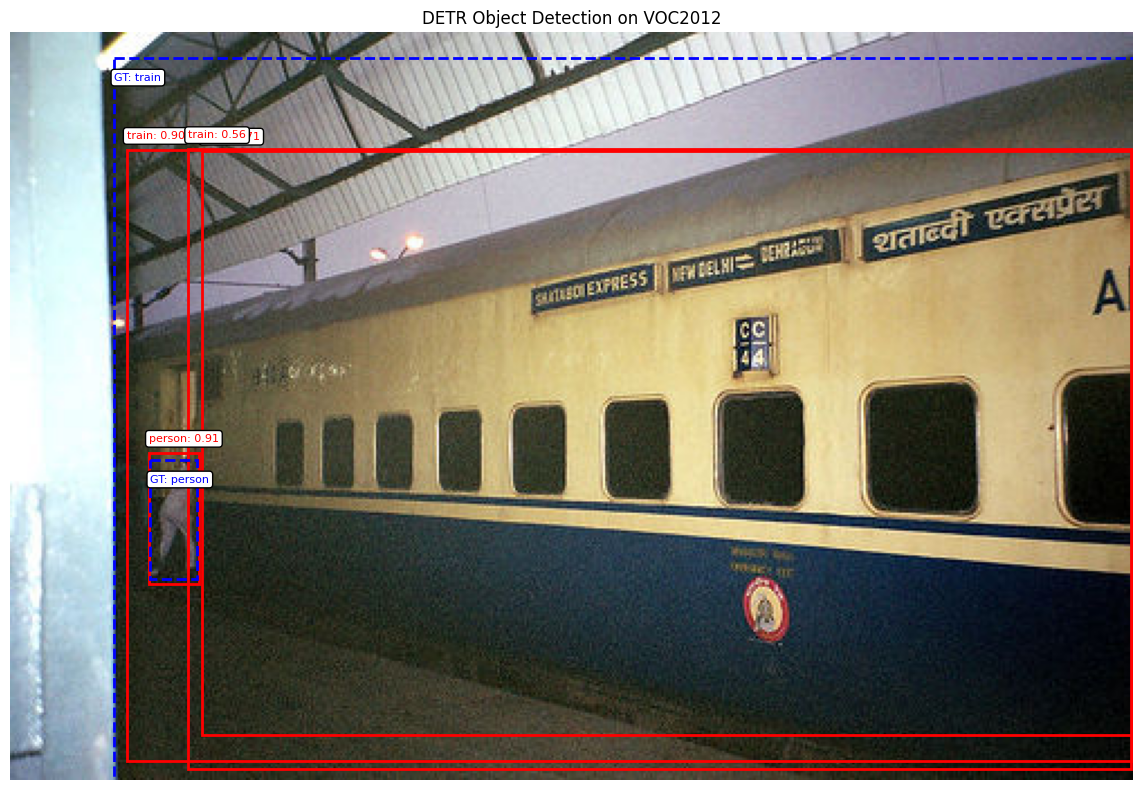

Sample 2:
  Ground truth objects: 2
  Predicted objects: 4
  High-confidence predictions: 4
--------------------------------------------------


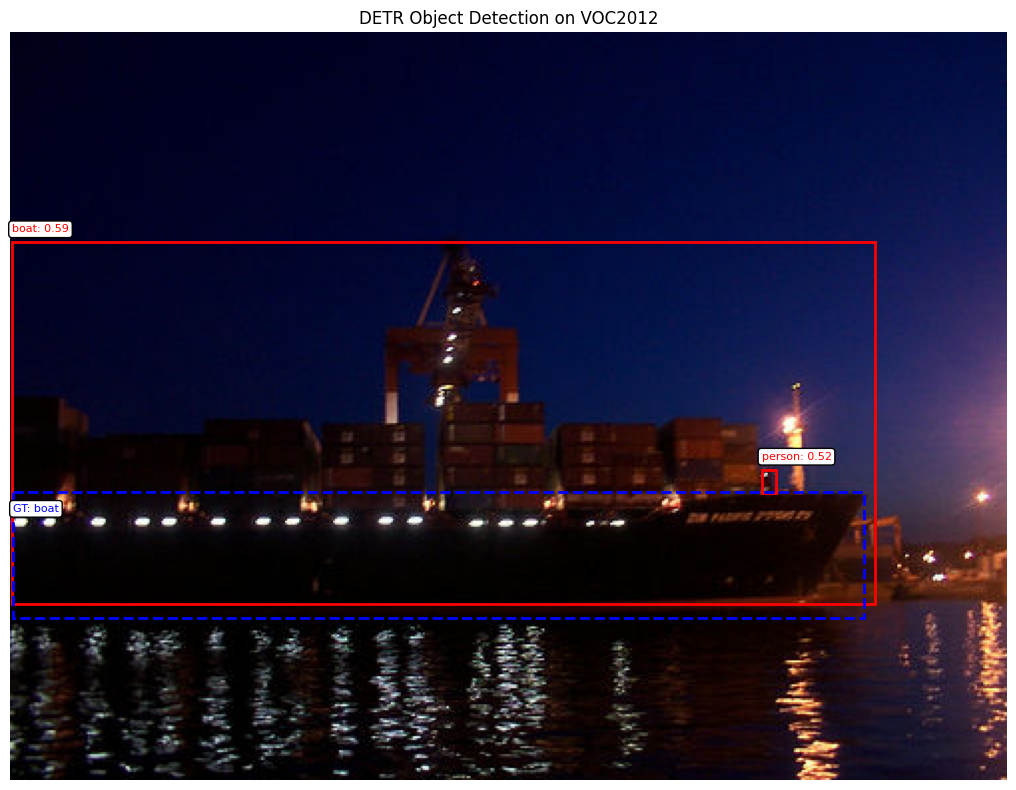

Sample 3:
  Ground truth objects: 1
  Predicted objects: 2
  High-confidence predictions: 2
--------------------------------------------------


In [9]:
for idx in range(3):
    image, annotation = dataset[idx]

    # prepare inputs for DETR
    inputs = processor(images=image, return_tensors="pt")

    # run inference
    with torch.no_grad():
        outputs = model(**inputs)

    # post-process outputs
    target_sizes = torch.tensor([image.size[::-1]])  # (height, width)
    results = processor.post_process_object_detection(
        outputs, 
        target_sizes=target_sizes, 
        threshold=0.5
    )[0]

    gt_boxes, gt_labels = parse_voc_annotation(annotation)

    gt_boxes = np.array(gt_boxes) if gt_boxes else None

    show_detection_result(image, results, gt_boxes, gt_labels)

    print(f"Sample {idx + 1}:")
    print(f"  Ground truth objects: {len(gt_boxes) if gt_boxes is not None else 0}")
    print(f"  Predicted objects: {len(results['boxes'])}")
    print(f"  High-confidence predictions: {sum(results['scores'] > 0.5)}")
    print("-" * 50) 